In [1]:
#import libraries

import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
#load data
NOAA_SFO_df = pd.read_parquet(
    "../Data_Preprocessing/data/NOAA_SFO_2022_2026_cleaned.parquet"
)

NOAA_SFO_df.head()

,DATE,Year,Month,Day,Hour,Minute,LATITUDE,LONGITUDE,ELEVATION,temperature,...,wind_speed,wind_direction,sea_level_pressure,station_level_pressure,wet_bulb_temperature,ceiling_height,altimeter,sky_condition_baseht,sky_cover_summation_baseht_1,precipitation
0,2022-01-01 00:00:00,2022,1,1,0,0,37.6197,-122.3656,3.0,11.7,...,7.7,290.0,1012.4,1009.4,8.2,22000.0,NaN,800.0,NaN,NaN
1,2022-01-01 00:56:00,2022,1,1,0,56,37.6197,-122.3656,3.0,10.6,...,7.2,300.0,1012.8,1012.3,7.9,22000.0,1012.9,610.0,610.0,0.0
2,2022-01-01 01:56:00,2022,1,1,1,56,37.6197,-122.3656,3.0,10.0,...,5.1,300.0,1013.3,1012.6,7.4,22000.0,1013.2,579.0,579.0,0.0
3,2022-01-01 02:56:00,2022,1,1,2,56,37.6197,-122.3656,3.0,9.4,...,5.1,290.0,1014.0,1013.6,7.1,22000.0,1014.2,NaN,NaN,0.0
4,2022-01-01 03:56:00,2022,1,1,3,56,37.6197,-122.3656,3.0,9.4,...,5.1,310.0,1014.6,1014.0,7.3,22000.0,1014.6,914.0,914.0,0.0


**Split training and test data for EDA purposes**
60/20/20 training/test/validation split. it is crucial we do not perform EDA on test and validation dataset

In [3]:
#First split:
# train = oldest 60%
# temp = most recent 40%
NOAA_train_df, NOAA_temp_df = train_test_split(
    NOAA_SFO_df,
    test_size=0.40,
    shuffle=False
)

# Second split:
# test = older half of temp, so subsequent 20%
# validation = newer half of temp, so most recent 20%
NOAA_test_df, NOAA_val_df = train_test_split(
    NOAA_temp_df,
    test_size=0.50,
    shuffle=False
)

# Check shapes
print(f"Training shape: {NOAA_train_df.shape}")
print(f"Test shape: {NOAA_test_df.shape}")
print(f"Validation shape: {NOAA_val_df.shape}")

Training shape: (32271, 23)
Test shape: (10757, 23)
Validation shape: (10757, 23)


In [4]:
#Verify split by confirming date 

print("Training date range:")
print(NOAA_train_df["DATE"].min(), "to", NOAA_train_df["DATE"].max())

print("\nTest date range:")
print(NOAA_test_df["DATE"].min(), "to", NOAA_test_df["DATE"].max())

print("\nValidation date range:")
print(NOAA_val_df["DATE"].min(), "to", NOAA_val_df["DATE"].max())

Training date range:
2022-01-01 00:00:00 to 2024-09-20 01:56:00

Test date range:
2024-09-20 02:39:00 to 2025-07-20 19:56:00

Validation date range:
2025-07-20 20:56:00 to 2026-06-09 16:56:00


**Perform EDA**

Describe columns

In [5]:
display(NOAA_train_df.describe().T)

,count,mean,min,25%,50%,75%,max,std
DATE,32271,2023-05-26 03:27:34.438970,2022-01-01 00:00:00,2022-09-20 03:26:00,2023-05-31 11:56:00,2024-02-01 15:37:30,2024-09-20 01:56:00,NaN
Year,32271.0,2022.935887,2022.0,2022.0,2023.0,2024.0,2024.0,0.795641
Month,32271.0,6.065291,1.0,3.0,6.0,9.0,12.0,3.343682
Day,32271.0,15.586998,1.0,8.0,15.0,23.0,31.0,8.818803
Hour,32271.0,11.27173,0.0,6.0,12.0,17.0,23.0,6.875353
Minute,32271.0,44.826005,0.0,54.0,56.0,56.0,59.0,21.346586
LATITUDE,32271.0,37.6197,37.6197,37.6197,37.6197,37.6197,37.6197,0.0
LONGITUDE,32271.0,-122.3656,-122.3656,-122.3656,-122.3656,-122.3656,-122.3656,0.0
ELEVATION,32271.0,3.0,3.0,3.0,3.0,3.0,3.0,0.0
temperature,32271.0,14.397756,2.2,11.7,13.9,16.7,36.7,3.926582


Distribution of float features

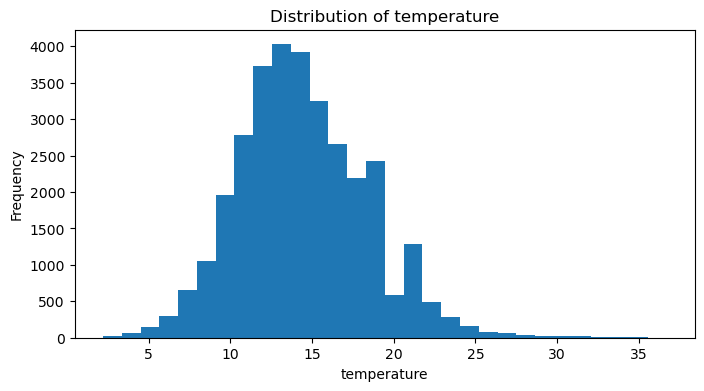

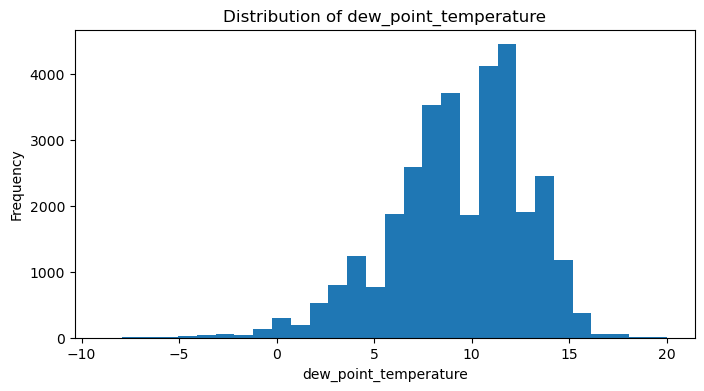

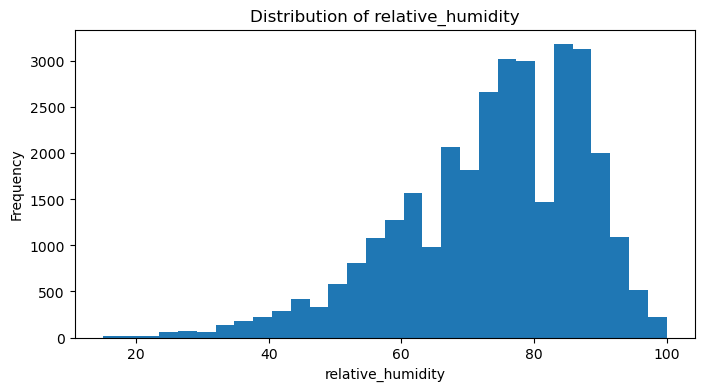

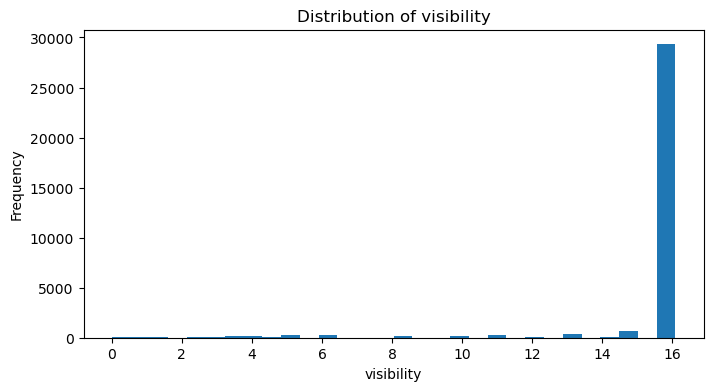

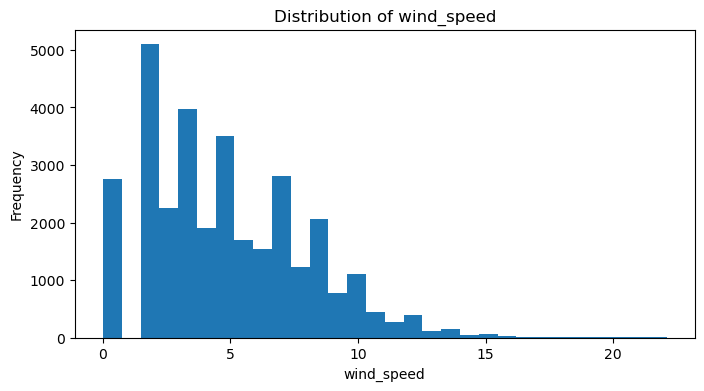

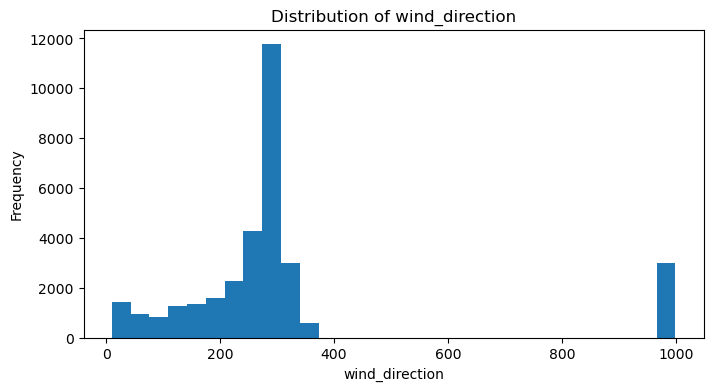

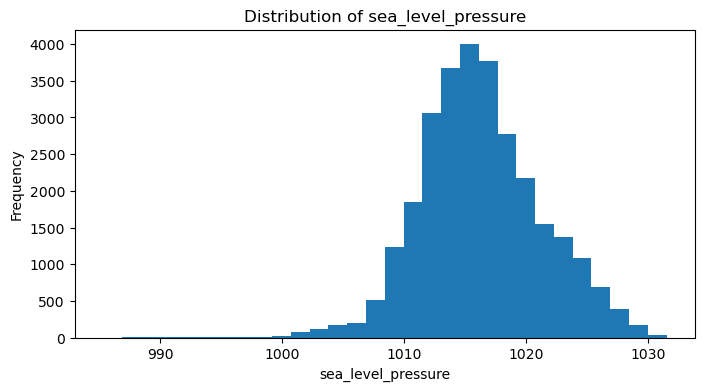

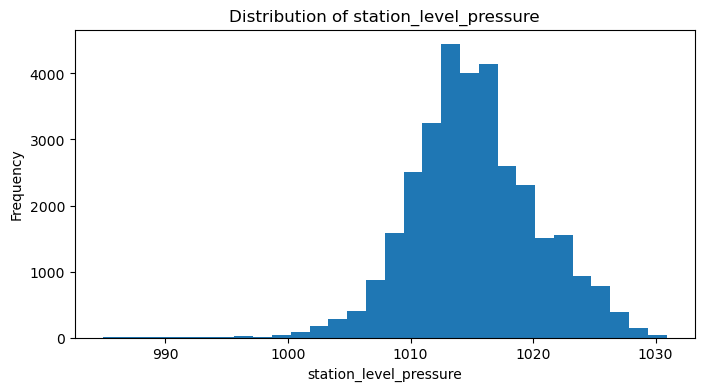

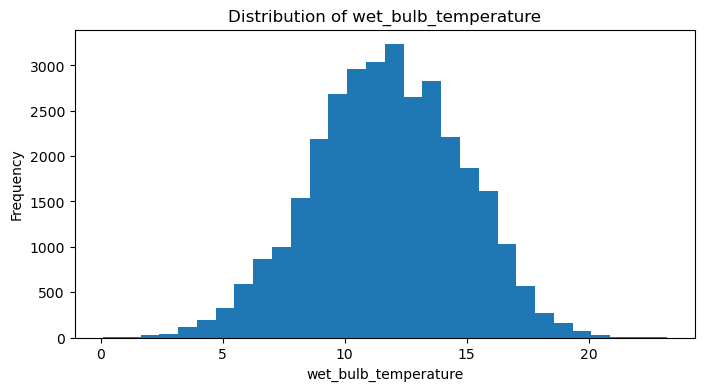

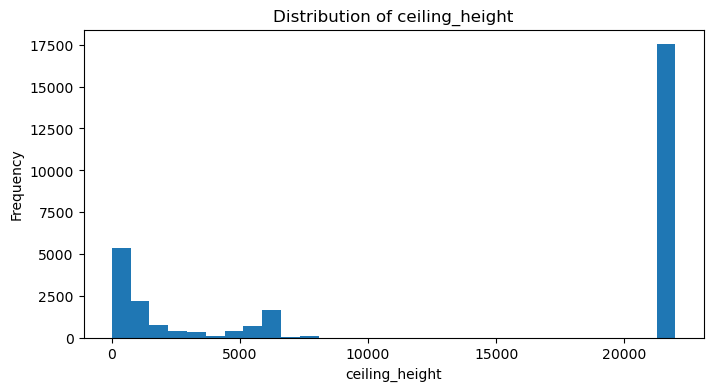

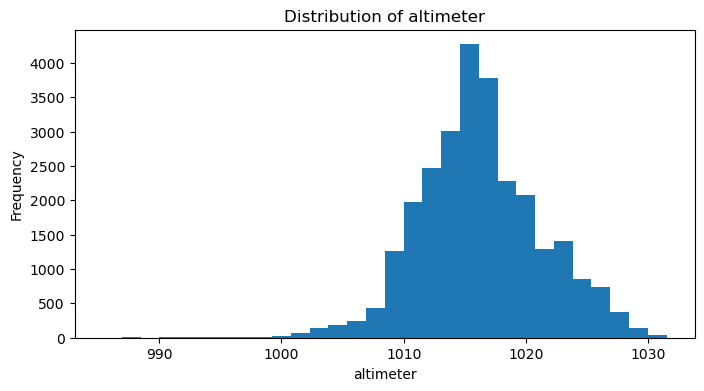

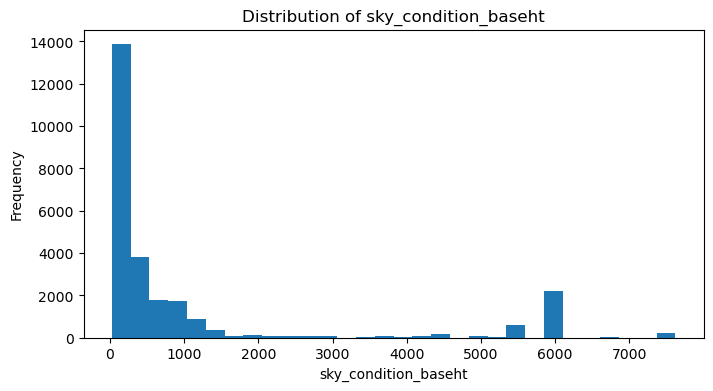

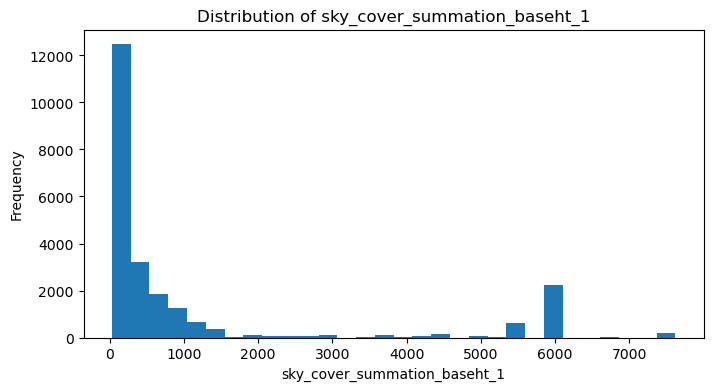

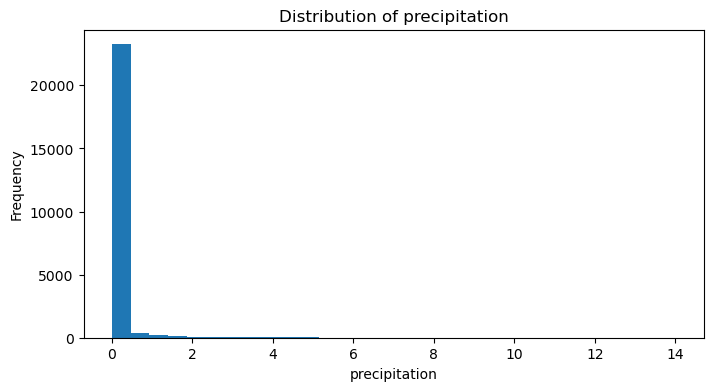

In [6]:
distribution_plot_columns = [
    "temperature",
    "dew_point_temperature",
    "relative_humidity",
    "visibility",
    "wind_speed",
    "wind_direction",
    "sea_level_pressure",
    "station_level_pressure",
    "wet_bulb_temperature",
    "ceiling_height",
    "altimeter",
    "sky_condition_baseht",
    "sky_cover_summation_baseht_1",
    "precipitation"
]

for col in distribution_plot_columns:
    plt.figure(figsize=(8, 4))
    plt.hist(NOAA_train_df[col].dropna(), bins=30)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {col}")
    plt.show()

Monthly trends

In [7]:
#Distribution plots of weather information

#create monthly trends
monthly_trend = [
    "temperature",
    "wind_speed",
    "visibility",
    "precipitation",
    "relative_humidity",
    "sea_level_pressure",
    "station_level_pressure",
    "altimeter"

]

# Create month/year bin
NOAA_train_df["Month_Year"] = NOAA_train_df["DATE"].dt.to_period("M")

# Calculate monthly average temperature
monthly_weather = NOAA_train_df.groupby("Month_Year")[monthly_trend].mean().reset_index()

# Convert Month_Year back to timestamp for plotting
monthly_weather["Month_Year"] = monthly_weather["Month_Year"].dt.to_timestamp()

**Monthly trend overlayed**

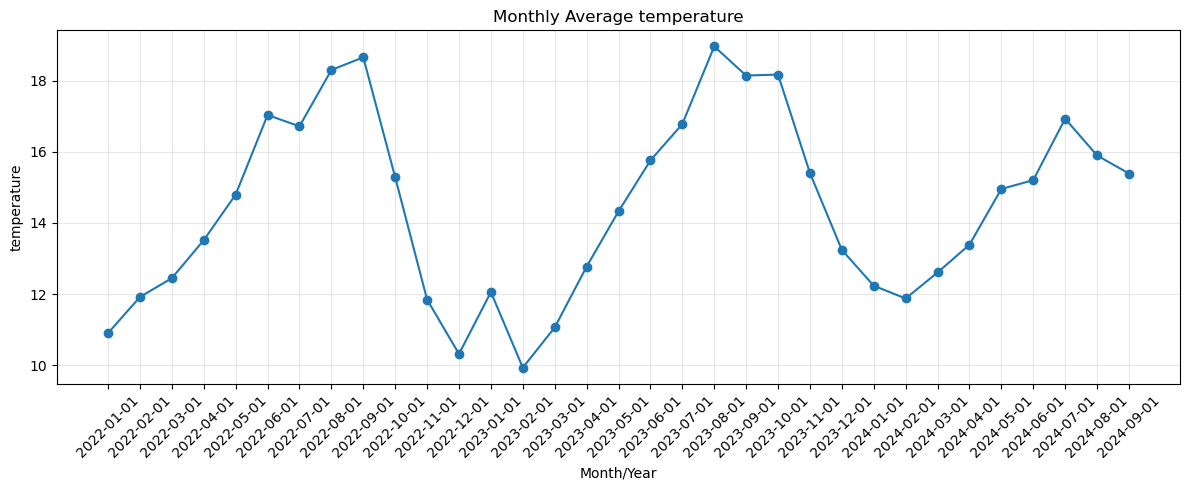

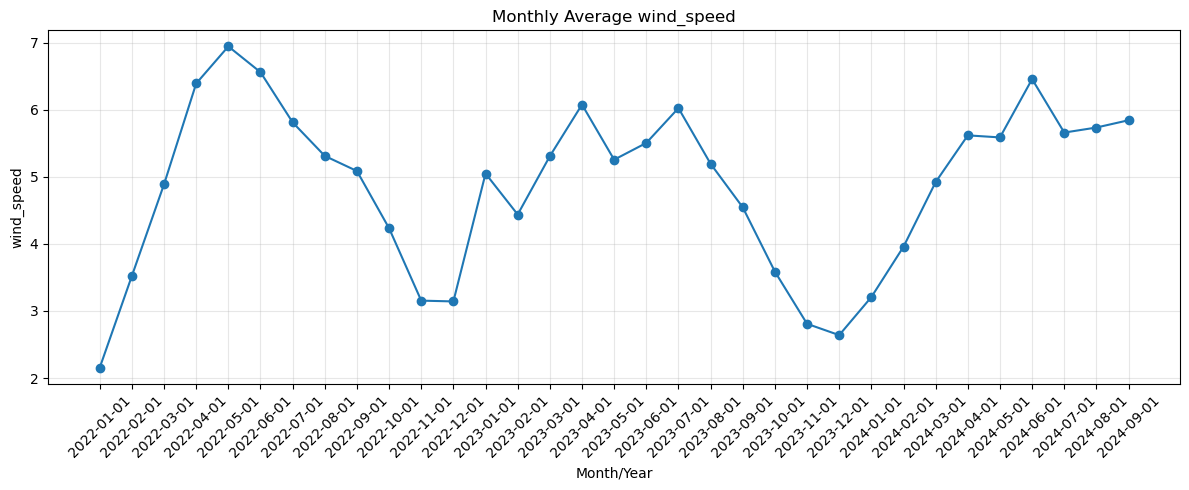

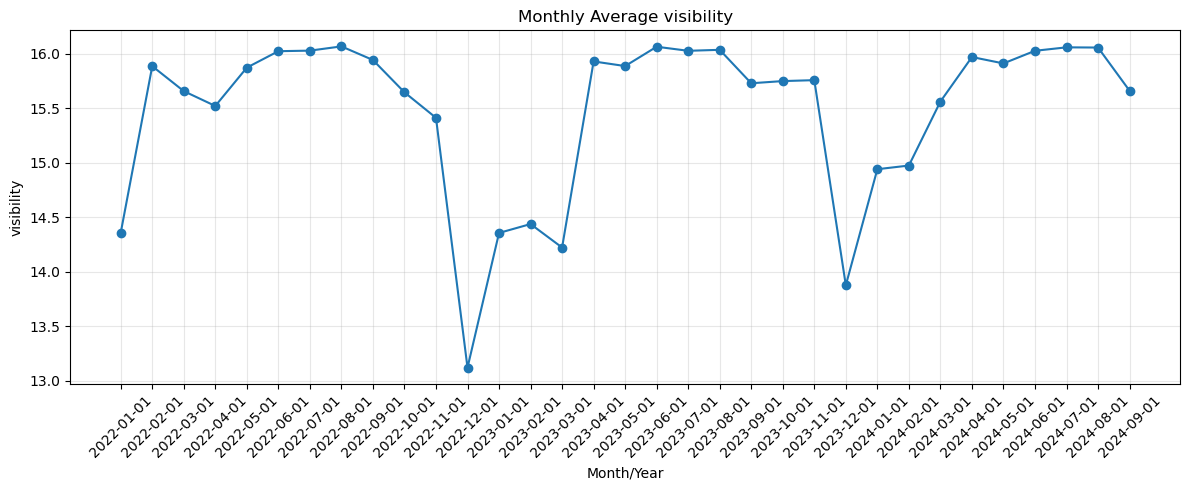

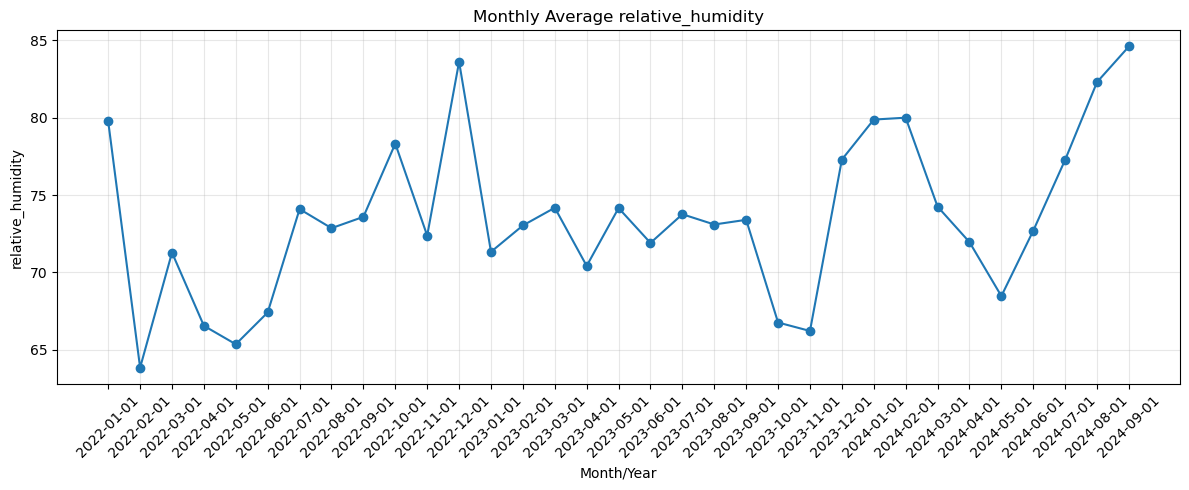

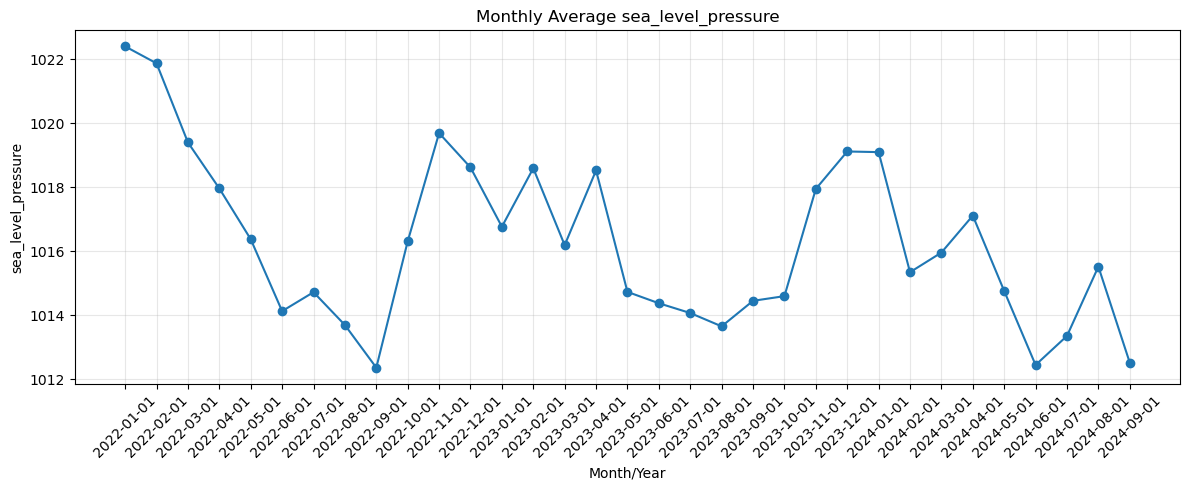

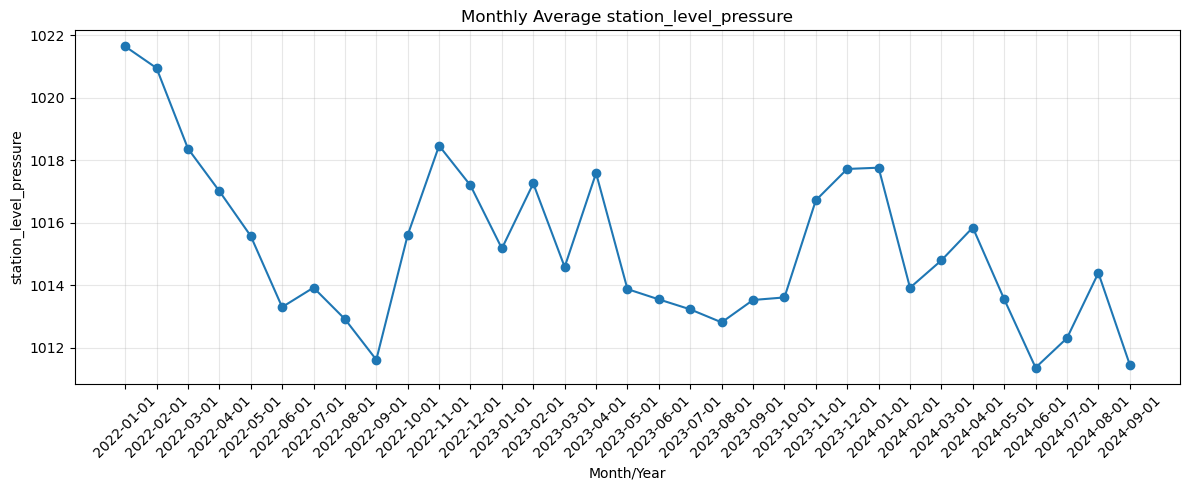

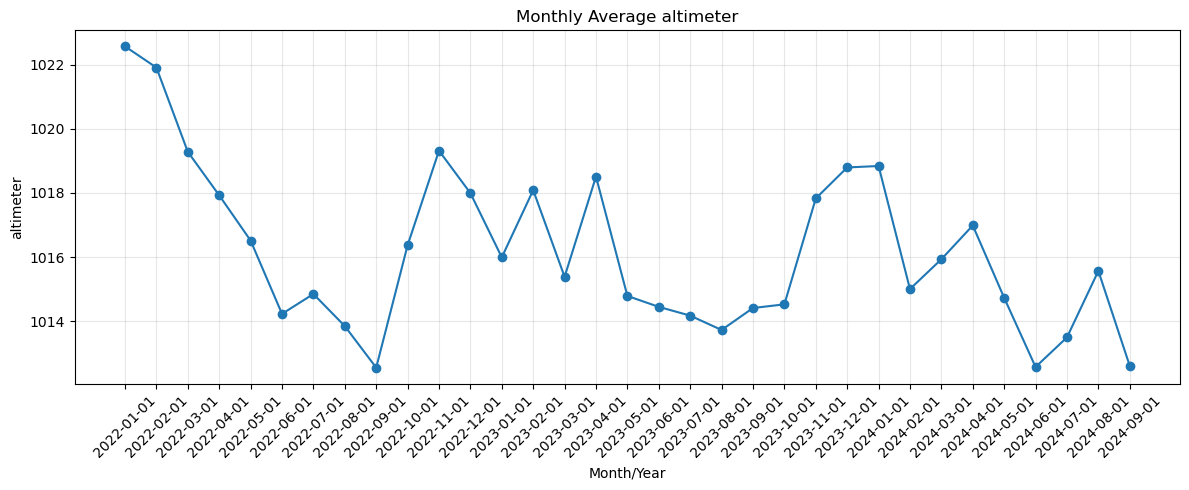

In [14]:
monthly_trend = [
    "temperature",
    "wind_speed",
    "visibility",
    "relative_humidity",
    "sea_level_pressure",
    "station_level_pressure",
    "altimeter"
]

for col in monthly_trend:
    plt.figure(figsize=(12, 5))
    
    plt.plot(monthly_weather["Month_Year"].astype(str), monthly_weather[col], marker="o")
    
    plt.title(f"Monthly Average {col}")
    plt.xlabel("Month/Year")
    plt.ylabel(col)
    plt.xticks(rotation=45)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

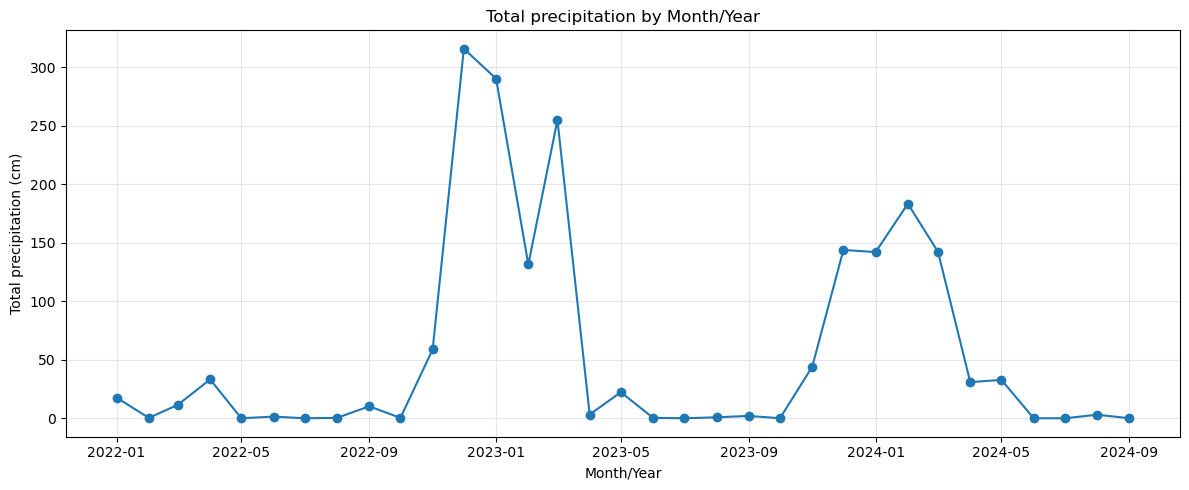

In [15]:
# we should probably do total precipitation here

monthly_precip = NOAA_train_df.groupby("Month_Year")["precipitation"].sum().reset_index()
monthly_precip["Month_Year"] = monthly_precip["Month_Year"].dt.to_timestamp()


plt.figure(figsize=(12, 5))
plt.plot(monthly_precip["Month_Year"], monthly_precip["precipitation"],marker="o")
plt.xlabel("Month/Year")
plt.ylabel("Total precipitation (cm)")
plt.title("Total precipitation by Month/Year")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Boxplot of some features by month**

<Figure size 1000x500 with 0 Axes>

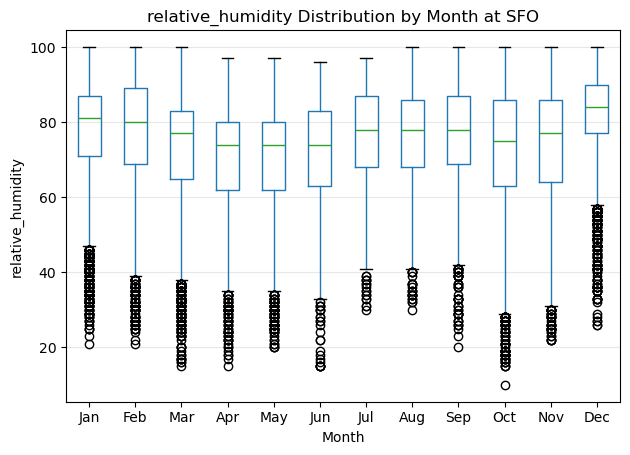

<Figure size 1000x500 with 0 Axes>

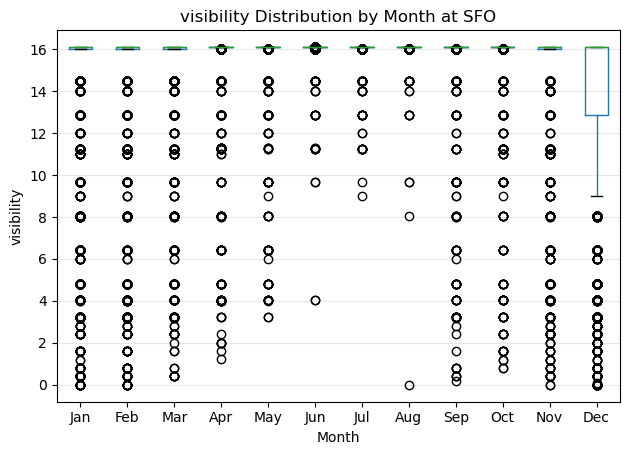

<Figure size 1000x500 with 0 Axes>

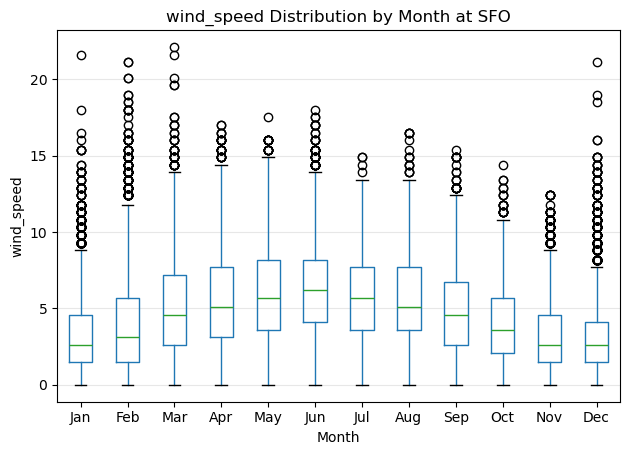

<Figure size 1000x500 with 0 Axes>

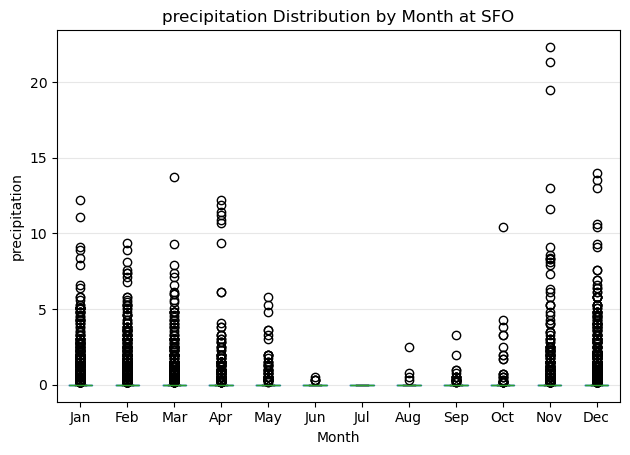

In [20]:
# Make sure Month exists
NOAA_SFO_df["Month"] = NOAA_SFO_df["DATE"].dt.month

boxplot_columns = [
    "relative_humidity",
    "visibility",
    "wind_speed",
    "precipitation"
]

for col in boxplot_columns:
    plt.figure(figsize=(10, 5))
    
    NOAA_SFO_df.boxplot(
        column=col,
        by="Month",
        grid=False
    )
    
    plt.title(f"{col} Distribution by Month at SFO")
    plt.suptitle("")
    plt.xlabel("Month")
    plt.ylabel(col)
    
    plt.xticks(
        ticks=range(1, 13),
        labels=["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
    )
    
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

**Correlation Matrix**

In [18]:
corr = NOAA_train_df[distribution_plot_columns].corr()

display(corr)

,temperature,dew_point_temperature,relative_humidity,visibility,wind_speed,wind_direction,sea_level_pressure,station_level_pressure,wet_bulb_temperature,ceiling_height,altimeter,sky_condition_baseht,sky_cover_summation_baseht_1,precipitation
temperature,1.000000,0.601902,-0.508814,0.147676,0.276490,-0.088892,-0.328281,-0.300977,0.902269,0.146980,-0.303689,-0.027949,-0.023667,-0.089076
dew_point_temperature,0.601902,1.000000,0.366324,-0.053954,0.106146,-0.101169,-0.425562,-0.397065,0.884758,-0.110392,-0.404798,-0.360875,-0.367179,0.025792
relative_humidity,-0.508814,0.366324,1.000000,-0.264095,-0.226240,0.005316,-0.083775,-0.081696,-0.097974,-0.303639,-0.086586,-0.355005,-0.367607,0.148740
visibility,0.147676,-0.053954,-0.264095,1.000000,-0.004224,0.035695,0.072539,0.077396,0.056174,0.286403,0.088019,0.110454,0.120244,-0.491480
wind_speed,0.276490,0.106146,-0.226240,-0.004224,1.000000,-0.338002,-0.301124,-0.302622,0.217827,0.039256,-0.307128,-0.196385,-0.202561,0.081719
wind_direction,-0.088892,-0.101169,0.005316,0.035695,-0.338002,1.000000,0.127637,0.130034,-0.107213,0.080569,0.137399,0.110319,0.113787,-0.060398
sea_level_pressure,-0.328281,-0.425562,-0.083775,0.072539,-0.301124,0.127637,1.000000,0.980506,-0.417253,0.109167,0.999736,0.287988,0.304328,-0.181112
station_level_pressure,-0.300977,-0.397065,-0.081696,0.077396,-0.302622,0.130034,0.980506,1.000000,-0.385969,0.090841,0.999997,0.296367,0.284443,-0.205705
wet_bulb_temperature,0.902269,0.884758,-0.097974,0.056174,0.217827,-0.107213,-0.417253,-0.385969,1.000000,0.022466,-0.391197,-0.207120,-0.207917,-0.037859
ceiling_height,0.146980,-0.110392,-0.303639,0.286403,0.039256,0.080569,0.109167,0.090841,0.022466,1.000000,0.131370,0.151990,0.191975,-0.201253


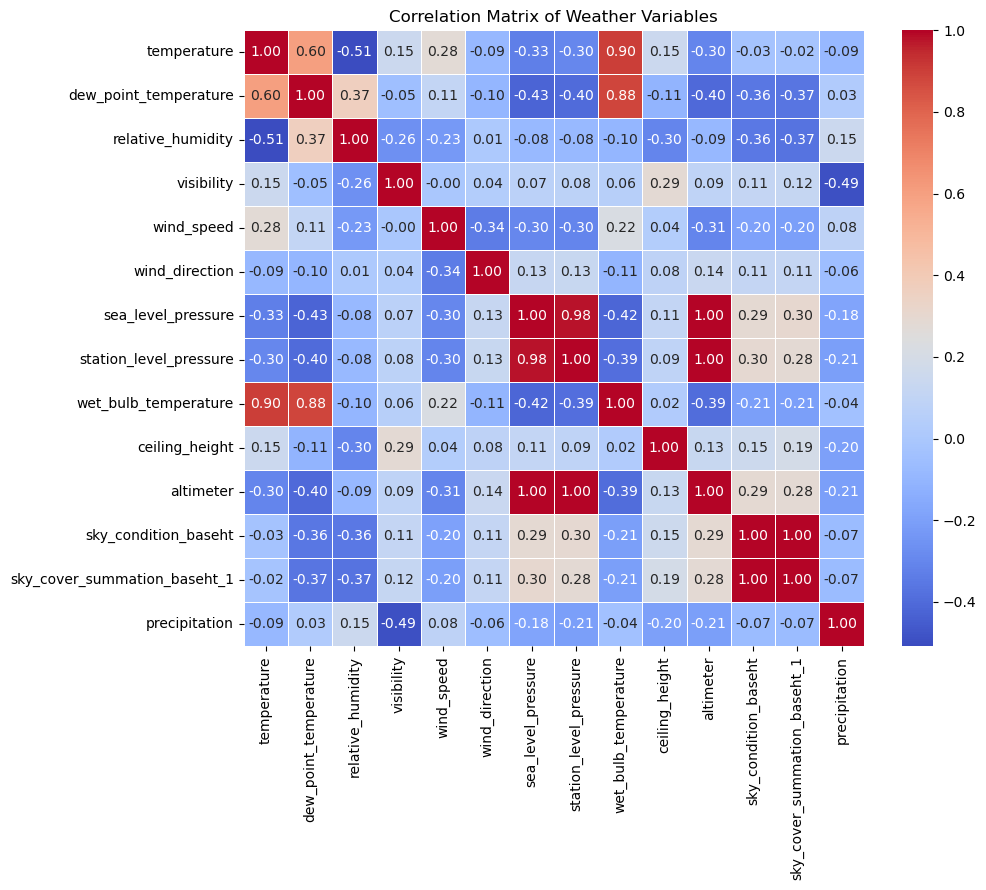

In [19]:
# Plot correlation matrix
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Weather Variables")
plt.show()